In [20]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully!


In [21]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

In [22]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        preciseMarker.id AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
session_first_start_last_end AS (
    SELECT
        sei.session_task_id,
        MIN(sei.start_index) AS first_start_index,
        MAX(sei.next_end_index) AS last_end_index
    FROM start_end_indices sei
    GROUP BY sei.session_task_id
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        CASE WHEN rtParent.title != 'No Gesture' and smt.group_id is not null THEN rtParent.title ELSE 'No Gesture' END AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title != 'No Gesture' and smt.group_id is not null THEN 1 ELSE 0 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    left JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    left JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
     JOIN session_first_start_last_end sfsle
      ON sd.session_task_id = sfsle.session_task_id
        AND sd.session_task_row_index BETWEEN sfsle.first_start_index AND sfsle.last_end_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [23]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [24]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [25]:
is_null = df_raw["group_id"].isnull()
null_block_start = is_null & (~is_null.shift(1, fill_value=False))
block_ids = null_block_start.cumsum()
df_raw["group_id"] = df_raw["group_id"].fillna("no_gesture_block_" + block_ids.astype(str))

In [26]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [27]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
No Gesture                        230485
Pinch Swipe                        12037
Tap and Hold                       11985
Spread Swipe                        9049
Single Swipe                        6072
Two-Finger Opposite Double Tap      3010
Two-Finger Double Tap               3001
Double Tap                          2784
Two-Finger Opposite Tap             1719
Two-Finger Tap                      1646
Single Tap                          1407
Name: count, dtype: int64

In [28]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    36375
6331fbd1-76bb-48d6-92a2-80a55a70d134    31589
696b4743-9d39-4fb1-8271-90e7d48652af    21096
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    43728
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    33659
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    39524
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    35425
fdd02af8-c764-43ba-8247-c612f85568b4    41799
dtype: int64

In [29]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [30]:
TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

In [31]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


In [32]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean.isna().sum()

id                        0
session_task_id           0
session_task_row_index    0
timestamp                 0
timestamp_ms              0
button_pressed            0
motor_angle               0
gesture                   0
parent_gesture            0
participant_id            0
is_gesture                0
group_id                  0
estimated_timestamp       0
touch_1_position          0
touch_1_pressure          0
touch_1_channel           0
touch_2_position          0
touch_2_pressure          0
touch_2_channel           0
touch_3_position          0
touch_3_pressure          0
touch_3_channel           0
touch_4_position          0
touch_4_pressure          0
touch_4_channel           0
touch_5_position          0
touch_5_pressure          0
touch_5_channel           0
active_ids                0
dtype: int64

In [33]:
# Create sliding windows from the cleaned DataFrame
X_windows = []
y_windows = []
meta_data = []

WINDOW_SIZE = 200
WINDOW_STRIDE = 20

print("Creating sliding windows...")
for (session_task_id, participant_id), group in df_clean.groupby(['session_task_id', 'participant_id']):
    sensor_data = group[SENSOR_COLUMNS].values
    labels = group[LABEL_COLUMN].values
    is_gesture = group['is_gesture'].values

    num_samples = sensor_data.shape[0]
    for start in range(0, num_samples - WINDOW_SIZE + 1, WINDOW_STRIDE):
        end = start + WINDOW_SIZE
        window_data = sensor_data[start:end]
        window_labels = labels[start:end]

        majority_label = "No Gesture"
        # If there is a a gesture fully shown in this window (meaning there is is_gesture == 0, is_gesture == 1 and is_gesture == 0 again)
        gesture_indices = np.where(is_gesture[start:end] == 1)[0]
        if len(gesture_indices) > 0:
            first_gesture_index = gesture_indices[0]
            last_gesture_index = gesture_indices[-1]
            if first_gesture_index > 0 and last_gesture_index < WINDOW_SIZE - 1:
                majority_label = window_labels[first_gesture_index]

        if majority_label == 'No Gesture':
            continue
        
        X_windows.append(window_data)
        y_windows.append(majority_label)
        meta_data.append({
            'session_task_id': session_task_id,
            'participant_id': participant_id,
            'start_index': start,
            'end_index': end,
        })
X_windows = np.array(X_windows)
y_windows = np.array(y_windows)
meta_data_df = pd.DataFrame(meta_data)
print(f"Created {X_windows.shape[0]} windows of size {WINDOW_SIZE} samples.")
# Display the shape of the created windows
X_windows.shape, y_windows.shape, meta_data_df.shape

Creating sliding windows...
Created 4141 windows of size 200 samples.


((4141, 200, 17), (4141,), (4141, 4))

In [34]:
# Print the value counts of the labels in the windows
unique, counts = np.unique(y_windows, return_counts=True)
label_counts = dict(zip(unique, counts))
print("Window Label Counts:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Window Label Counts:
Double Tap: 487
Pinch Swipe: 250
Single Swipe: 342
Single Tap: 494
Spread Swipe: 279
Tap and Hold: 267
Two-Finger Double Tap: 473
Two-Finger Opposite Double Tap: 480
Two-Finger Opposite Tap: 521
Two-Finger Tap: 548


In [35]:
def extract_features(window, is_padded_window, TOUCH_MOVE_THRESHOLD=0.01):
    # 1. SETUP & INITIALIZATION
    features = []
    feature_names = []
    
    # Indices based on your sensor layout
    touch_channel_cols = [4, 7, 10, 13, 16]
    touch_pressure_cols = [3, 6, 9, 12, 15]
    touch_position_cols = [2, 5, 8, 11, 14]
    original_length_col = window.shape[1] - 1 # Assuming it's the last column
    
    # Required for the continuous touch logic
    original_length = int(window[0, original_length_col]) if is_padded_window else window.shape[0]

    def circular_range(angles):
        if len(angles) == 0: return 0
        sorted_angles = np.sort(angles)
        gaps = np.diff(sorted_angles)
        wrap_gap = (2 * np.pi - sorted_angles[-1]) + sorted_angles[0]
        all_gaps = np.append(gaps, wrap_gap)
        return 2 * np.pi - np.max(all_gaps)

    # 2. PRE-PROCESSING: Zero out inactive fingers
    # We work on a copy to avoid mutating the original window if it's used elsewhere
    working_window = window.copy()
    
    for i in range(len(touch_position_cols)):
        pos_idx = touch_position_cols[i]
        press_idx = touch_pressure_cols[i]
        chan_idx = touch_channel_cols[i]
        
        f_pressures = working_window[:, press_idx]
        f_positions = np.nan_to_num(working_window[:, pos_idx], nan=0.0)
        
        is_touching = f_pressures > 0
        
        if np.any(is_touching):
            # Calculate movement
            valid_positions = f_positions[is_touching]
            c_range = circular_range(valid_positions)
            has_moved = c_range > TOUCH_MOVE_THRESHOLD
            
            # Calculate continuity
            start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
            end_of_touches = is_touching & ~np.append(is_touching[1:], False)
            touch_durations = np.where(end_of_touches)[0] - np.where(start_of_touches)[0]
            min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
            is_continuous_touch = min_touch_duration >= original_length - 1
            
            # THE LOGIC: If not active/moving, zero out the finger data
            is_active = (has_moved or not is_continuous_touch)
            if not is_active:
                working_window[:, [pos_idx, press_idx, chan_idx]] = 0
        else:
            # If never touching, ensure it's 0
            working_window[:, [pos_idx, press_idx, chan_idx]] = 0

    # 3. FEATURE EXTRACTION (Now using working_window)
    touch_pressures = working_window[:, touch_pressure_cols]
    def add_feature(name, value):
        features.append(value)
        feature_names.append(name)

    # General Touch Activity Features
    active_touches = (touch_pressures > 0).astype(int)
    add_feature("max_simultaneous_touches", np.max(np.sum(active_touches, axis=1)))
    add_feature("avg_active_touches", np.mean(np.sum(active_touches, axis=1)))
    add_feature("any_touch", np.any(active_touches))
    add_feature("total_active_touch_samples", np.sum(active_touches))
    add_feature("total_pressure", np.sum(touch_pressures))
    add_feature("max_pressure", np.max(touch_pressures))
    
    non_zero_pressures = touch_pressures[touch_pressures > 0]
    add_feature("min_non_zero_pressure", np.min(non_zero_pressures) if len(non_zero_pressures) > 0 else 0)

    # --- Distances between fingers (using filtered working_window) ---
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    dist_idx = 0
    for p1_idx, p2_idx in combinations(range(5), 2):
        dist_idx += 1
        f1_pos = working_window[:, touch_position_cols[p1_idx]]
        f2_pos = working_window[:, touch_position_cols[p2_idx]]
        f1_press = working_window[:, touch_pressure_cols[p1_idx]]
        f2_press = working_window[:, touch_pressure_cols[p2_idx]]
        
        valid_dist_mask = (f1_press > 0) & (f2_press > 0)
        distances = short_dist(f1_pos[valid_dist_mask], f2_pos[valid_dist_mask])

        # Split the distances in 5 equal bins and get the distance values per bin for better time perception
        distance_parts = np.array_split(distances, 5)
        for bin_idx, part in enumerate(distance_parts):
            add_feature(f"finger_distance_{dist_idx}_bin_{bin_idx+1}_mean", np.mean(part) if len(part) > 0 else 0)
            add_feature(f"finger_distance_{dist_idx}_bin_{bin_idx+1}_max", np.max(part) if len(part) > 0 else 0)
            add_feature(f"finger_distance_{dist_idx}_bin_{bin_idx+1}_min", np.min(part) if len(part) > 0 else 0)

        has_distance = len(distances) != 0
        add_feature(f"finger_distance_{dist_idx}_mean", np.mean(distances) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_max", np.max(distances) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_min", np.min(distances) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_q25", np.percentile(distances, 25) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_q75", np.percentile(distances, 75) if has_distance else 0)

    # --- Per Finger Features ---
    amount_active_moving_fingers = 0
    for i in range(len(touch_position_cols)):
        finger_positions = working_window[:, touch_position_cols[i]]
        finger_pressures = working_window[:, touch_pressure_cols[i]]
        finger_channels = working_window[:, touch_channel_cols[i]]

        is_touching = finger_pressures > 0
        # Re-calculating these for the specific finger features
        circle_range = circular_range(finger_positions[is_touching]) if np.any(is_touching) else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        
        # Continuity check for the count
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_durations = np.where(end_of_touches)[0] - np.where(start_of_touches)[0]
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        is_continuous_touch = min_touch_duration >= original_length - 1

        # General
        # 1. Any touch activity?
        is_touching = finger_pressures > 0
        add_feature(f"finger_{i+1}_any_touch", np.any(is_touching))
        # 3. Has moved? (this has a threshold to avoid noise)
        circle_range = circular_range(finger_positions) if len(finger_positions) > 0 else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        add_feature(f"finger_{i+1}_has_moved", has_moved)

        # 4. Amount of reactivations (so how often was the finger lifted and put down again)
        touch_reactivations = 0
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                touch_reactivations += 1
        add_feature(f"finger_{i+1}_touch_reactivations", touch_reactivations)

        # Touch Times and Amount (Pressure is 0 or null if no touch) There might be multiple touches in a window for a given finger, so we have to extract each consecutive time a touch was active, plus the amount of samples for each time.
        # start_of_touches = is_touching & (~is_touching.shift(1, fill_value=False))
        # end_of_touches = is_touching & (~is_touching.shift(-1, fill_value=False))
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_starts = np.where(start_of_touches)[0]
        touch_ends = np.where(end_of_touches)[0]
        touch_durations = touch_ends - touch_starts

        max_touch_duration = np.max(touch_durations) if len(touch_durations) > 0 else 0
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        
        # Is continuously pressed during the window? (If the min touch duration is the length of the window)
        is_continuous_touch = min_touch_duration >= original_length - 1
        add_feature(f"finger_{i+1}_continuous_touch_duration", min_touch_duration if is_continuous_touch else 0)
        add_feature(f"finger_{i+1}_non_continuous_touch_duration", 0 if is_continuous_touch else np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_is_continuous_touch", is_continuous_touch)

        if np.any(is_touching) and (has_moved or not is_continuous_touch):
            amount_active_moving_fingers += 1

        # 4. How many times was the finger touched?
        add_feature(f"finger_{i+1}_touch_starts", len(touch_starts))
        add_feature(f"finger_{i+1}_touch_ends", len(touch_ends))
        # 5. Mean touch duration
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        # 6. Std Dev touch duration
        add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        # 7. Max touch duration
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        # 8. Min touch duration
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        # 9. Range touch duration
        add_feature(f"finger_{i+1}_range_touch_duration", np.abs(max_touch_duration - min_touch_duration) if len(touch_durations) > 0 else 0)
        # 10. Total touch duration
        add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)

        # Position, Pressure Features
        for data_type, data in [("positions", finger_positions), ("pressures", finger_pressures), ("channels", finger_channels)]:
            # If the data is empty, add zeros for all features
            has_data = len(data) != 0
            # 1. Mean pressure
            add_feature(f"finger_{i+1}_{data_type}_mean", np.mean(data) if has_data else 0)
            # 2. Std Dev pressure
            add_feature(f"finger_{i+1}_{data_type}_std", np.std(data) if has_data else 0)
            # 3. Max pressure
            add_feature(f"finger_{i+1}_{data_type}_max", np.max(data) if has_data else 0)
            # 4. Min pressure
            add_feature(f"finger_{i+1}_{data_type}_min", np.min(data) if has_data else 0)
            # 5. Range pressure
            add_feature(f"finger_{i+1}_{data_type}_range", circular_range(data) if has_data else 0)
            # 7. Q25 / Q75
            add_feature(f"finger_{i+1}_{data_type}_q25", np.percentile(data, 25) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_q75", np.percentile(data, 75) if has_data else 0)

    add_feature("active_moving_fingers", amount_active_moving_fingers)

    return np.array(features, dtype=np.float32), feature_names

In [36]:
le = LabelEncoder()
y_windows_encoded = le.fit_transform(y_windows)

In [37]:
# Store label encoder
import pickle
with open("class_gesture_classic_label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [38]:
# Print nan for both datasets before feature extraction
print(f"NaN in windows before feature extraction: {np.isnan(X_windows).any()}")

NaN in windows before feature extraction: False


In [39]:
feature_names = extract_features(X_windows[0], False)[1]
# Extract the Features for all windows (ignoring feature names)
X_windows_extracted = np.array([extract_features(win, False)[0] for win in X_windows], dtype=np.float32)
print(f"Extracted features shape: {X_windows_extracted.shape}")  # should be (N_windows, N_features)

Extracted features shape: (4141, 383)


In [40]:
# Print nan for both datasets after feature extraction
print(f"NaN in windows after feature extraction: {np.isnan(X_windows_extracted).any()}")

NaN in windows after feature extraction: False


In [41]:
# Set all nan values to 0
X_win = np.nan_to_num(X_windows_extracted, nan=0.0)

In [42]:
# Lets visualize the X_sequences for the "Double Tap" gesture
gesture_name = "Two-Finger Double Tap"
print("Values for gesture:", gesture_name)
gesture_index = np.where(le.classes_ == gesture_name)[0][0]
indices = np.where(y_windows_encoded == gesture_index)[0]
if len(indices) == 0:
    print(f"No samples found for gesture: {gesture_name}")
else:
    sample_index = indices[0]
    sample_features = X_win[sample_index]

    # Print the values with the feature name for this row
    for fname, fvalue in zip(feature_names, sample_features):
        print(f"{fname}: {fvalue}")

Values for gesture: Two-Finger Double Tap
max_simultaneous_touches: 2.0
avg_active_touches: 0.7749999761581421
any_touch: 1.0
total_active_touch_samples: 155.0
total_pressure: 71.9591064453125
max_pressure: 0.57012540102005
min_non_zero_pressure: 0.0022805016487836838
finger_distance_1_bin_1_mean: 0.0
finger_distance_1_bin_1_max: 0.0
finger_distance_1_bin_1_min: 0.0
finger_distance_1_bin_2_mean: 0.0
finger_distance_1_bin_2_max: 0.0
finger_distance_1_bin_2_min: 0.0
finger_distance_1_bin_3_mean: 0.0
finger_distance_1_bin_3_max: 0.0
finger_distance_1_bin_3_min: 0.0
finger_distance_1_bin_4_mean: 0.0
finger_distance_1_bin_4_max: 0.0
finger_distance_1_bin_4_min: 0.0
finger_distance_1_bin_5_mean: 0.0
finger_distance_1_bin_5_max: 0.0
finger_distance_1_bin_5_min: 0.0
finger_distance_1_mean: 0.0
finger_distance_1_max: 0.0
finger_distance_1_min: 0.0
finger_distance_1_q25: 0.0
finger_distance_1_q75: 0.0
finger_distance_2_bin_1_mean: 0.0
finger_distance_2_bin_1_max: 0.0
finger_distance_2_bin_1_min:

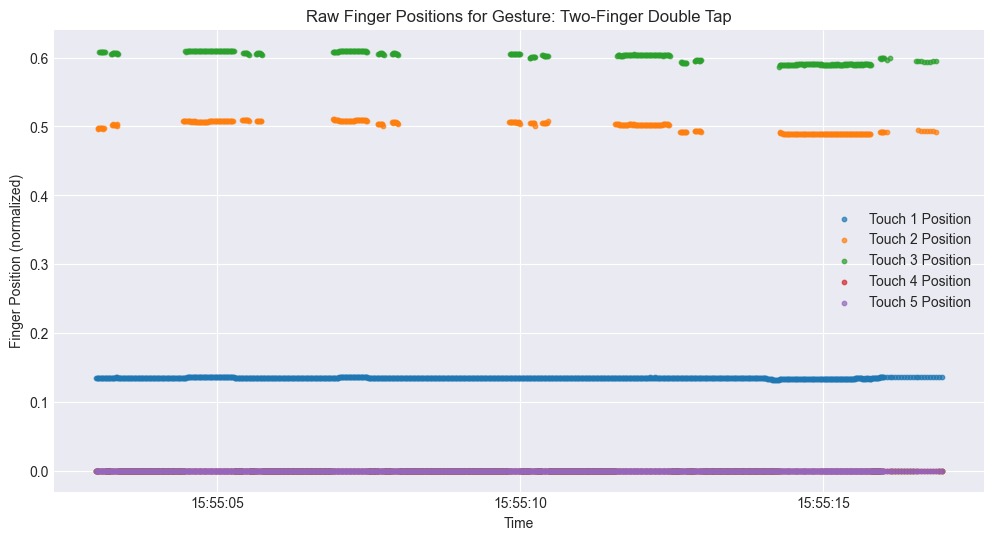

In [43]:
# Draw a graph of the raw finger position data for the same sample
raw_sample = df_clean[
    df_clean["session_task_id"] == meta_data_df.iloc[indices[0]]["session_task_id"]
]

plt.figure(figsize=(12, 6))

for i in range(5):
    pos_col = f'touch_{i+1}_position'
    plt.scatter(
        raw_sample['estimated_timestamp'],
        raw_sample[pos_col],
        s=10,        # point size
        alpha=0.7,   # transparency to reduce overplotting
        label=f'Touch {i+1} Position'
    )

plt.xlabel('Time')
plt.ylabel('Finger Position (normalized)')
plt.title(f'Raw Finger Positions for Gesture: {gesture_name}')
plt.legend()
plt.show()

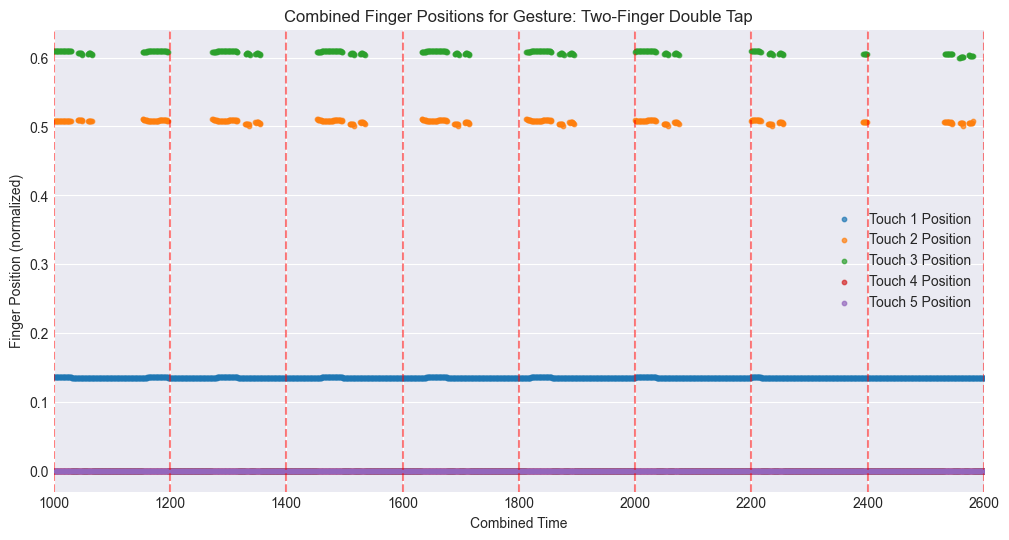

In [44]:
# Draw a graph of the finger positions for all windows that was classified as the gesture, as if they where performed right after one another, with vertical colored lines indicating the window boundaries
plt.figure(figsize=(12, 6))

indices_checked = set()
for i in range(5):
    pos_col = f'touch_{i+1}_position'
    combined_positions = []

    for idx in indices:
        window_start = meta_data_df.iloc[idx]['start_index']
        window_end = meta_data_df.iloc[idx]['end_index']
        session_id = meta_data_df.iloc[idx]['session_task_id']

        # continue if the session_task_id is not in raw_sample
        if session_id not in raw_sample['session_task_id'].values:
            continue

        # add to indices checekd
        indices_checked.add(idx)

        window_data = df_clean[
            df_clean['session_task_id'] == session_id
        ].iloc[window_start:window_end]

        combined_positions.extend(window_data[pos_col].values)

    combined_positions = np.array(combined_positions)
    x = np.arange(len(combined_positions))

    plt.scatter(
        x,
        combined_positions,
        s=10,              # marker size (adjust as needed)
        alpha=0.7,
        label=f'Touch {i+1} Position'
    )

plt.xlabel('Combined Time')
plt.ylabel('Finger Position (normalized)')
plt.title(f'Combined Finger Positions for Gesture: {gesture_name}')

# Draw vertical lines for window boundaries
for w in range(1, len(indices_checked)):
    plt.axvline(
        x=w * WINDOW_SIZE,
        color='red',
        linestyle='--',
        alpha=0.5
    )

plt.legend()
plt.xlim(1000, 2600)
plt.show()

In [45]:
participant_ids = meta_data_df['participant_id'].unique().tolist()
amount_of_participants = len(participant_ids)

train_pids = participant_ids[:amount_of_participants - 1]
test_pids = participant_ids[amount_of_participants - 1:]

print(f"Amount of participants: {amount_of_participants} (Train: {len(train_pids)}, Test: {len(test_pids)})")

Amount of participants: 8 (Train: 7, Test: 1)


In [46]:
# Split sliding windows
train_mask_win = meta_data_df['participant_id'].isin(train_pids)
X_train_win = X_win[train_mask_win]
y_train_win = y_windows_encoded[train_mask_win]

test_mask_win = meta_data_df['participant_id'].isin(test_pids)
X_test_win = X_win[test_mask_win]
y_test_win = y_windows_encoded[test_mask_win]

In [47]:
# For each label, print the amount of samples in each split
for label in le.classes_:
    label_int = le.transform([label])[0]
    train_count = np.sum(y_train_win == label_int)
    test_count = np.sum(y_test_win == label_int)
    print(f"Label: {label} | Train: {train_count} | Test: {test_count}")

Label: Double Tap | Train: 412 | Test: 75
Label: Pinch Swipe | Train: 231 | Test: 19
Label: Single Swipe | Train: 286 | Test: 56
Label: Single Tap | Train: 441 | Test: 53
Label: Spread Swipe | Train: 231 | Test: 48
Label: Tap and Hold | Train: 232 | Test: 35
Label: Two-Finger Double Tap | Train: 422 | Test: 51
Label: Two-Finger Opposite Double Tap | Train: 426 | Test: 54
Label: Two-Finger Opposite Tap | Train: 434 | Test: 87
Label: Two-Finger Tap | Train: 500 | Test: 48


In [48]:
# Print train / val / test shapes for windows for both full and windowed
print(f"Sliding Window Split:")
print(f"  X_train_win: {X_train_win.shape}, y_train_win: {y_train_win.shape}")
print(f"  X_test_win:  {X_test_win.shape},  y_test_win:  {y_test_win.shape}")

Sliding Window Split:
  X_train_win: (3615, 383), y_train_win: (3615,)
  X_test_win:  (526, 383),  y_test_win:  (526,)


In [49]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform, loguniform

MODEL_CONFIGS = [
    {
        "name": "RandomForest",
        "pipeline": Pipeline([
            ("clf", RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "param_grid": {
            "clf__n_estimators":      randint(200, 1000),
            "clf__max_depth":         [None, 8, 12, 20, 30],
            "clf__min_samples_split": randint(2, 20),
            "clf__min_samples_leaf":  randint(1, 10),
            "clf__max_features":      ["sqrt", "log2", 0.3, 0.5],
            "clf__class_weight":      [
                None, 
                "balanced",
                {0: 1, 1: 5},
                {0: 1, 1: 10},
                {0: 1, 1: 20},
                {0: 1, 1: 40},
            ],
        },
    },
    {
        "name": "GradientBoosting",
        "pipeline": Pipeline([
            ("clf", GradientBoostingClassifier(
                random_state=42
            ))
        ]),
        "param_grid": {
            "clf__n_estimators":   randint(100, 600),
            "clf__learning_rate":  loguniform(1e-2, 2e-1),
            "clf__max_depth":      randint(2, 6),
            "clf__subsample":      uniform(0.6, 0.4),   # 0.6–1.0
        },
    },
    {
        "name": "LogisticRegression",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                multi_class="multinomial",
                n_jobs=-1,
                solver="lbfgs"
            ))
        ]),
        "param_grid": {
            "clf__C":            loguniform(1e-3, 1e2),
            "clf__class_weight":      [
                None, 
                "balanced",
                {0: 1, 1: 5},
                {0: 1, 1: 10},
                {0: 1, 1: 20},
            ],
        },
    },
    {
        "name": "ExtraTrees",
        "pipeline": Pipeline([
            ("clf", ExtraTreesClassifier(
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "param_grid": {
            "clf__n_estimators":      randint(300, 1200),
            "clf__max_depth":         [None, 8, 12, 20, 30],
            "clf__min_samples_split": randint(2, 20),
            "clf__min_samples_leaf":  randint(1, 10),
            "clf__max_features":      ["sqrt", "log2", 0.3, 0.5],
            "clf__class_weight":      [
                None, 
                "balanced",
                {0: 1, 1: 5},
                {0: 1, 1: 10},
                {0: 1, 1: 20},
                {0: 1, 1: 40},
            ],
        },
    },
    {
        "name": "LinearSVC",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(
                max_iter=5000,
                dual=False
            ))
        ]),
        "param_grid": {
            "clf__C":            loguniform(1e-3, 1e2),
            "clf__class_weight":      [
                None, 
                "balanced",
                {0: 1, 1: 5},
                {0: 1, 1: 10},
                {0: 1, 1: 20},
                {0: 1, 1: 40},
            ],
        },
    },
    {
        "name": "AdaBoost",
        "pipeline": Pipeline([
            ("clf", AdaBoostClassifier(
                random_state=42
            ))
        ]),
        "param_grid": {
            "clf__n_estimators": randint(100, 600),
            "clf__learning_rate": loguniform(1e-2, 1.0),
        },
    }
]

In [50]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    f1_score,
)
import numpy as np
import pandas as pd

# SCORING = make_scorer(recall_score, pos_label=yes_label_int, average="macro")
SCORERS = {
    "recall": make_scorer(recall_score, average="macro"),
    "precision": make_scorer(precision_score, average="macro", zero_division=0),
    "f1": make_scorer(f1_score, average="macro"),
}

OPTIMIZE_METRIC = "f1"

gkf = GroupKFold(n_splits=amount_of_participants - 1)
groups_train = meta_data_df[train_mask_win]['participant_id'].values

best_model = None
best_model_name = None
best_score = -np.inf

rows = []
for cfg in MODEL_CONFIGS:
    name = cfg["name"]
    pipe = cfg["pipeline"]

    print(f"\n=== Tuning {name} ===")

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=cfg["param_grid"],
        n_iter=40,
        cv=gkf,
        scoring=SCORERS,
        refit=OPTIMIZE_METRIC,
        return_train_score=True,
        n_jobs=-1,
        verbose=1,
        random_state=42,
    )

    search.fit(X_train_win, y_train_win, groups=groups_train)

    idx = search.best_index_
    cv = search.cv_results_

    print(f"Best CV {OPTIMIZE_METRIC} Score: {cv[f'mean_test_{OPTIMIZE_METRIC}'][idx]:.4f}")

    # -----------------------------
    # Track best overall model
    # -----------------------------
    if cv[f"mean_test_{OPTIMIZE_METRIC}"][idx] > best_score:
        print("--> New Best Model Found!")
        best_score = cv[f"mean_test_{OPTIMIZE_METRIC}"][idx]
        best_model = search.best_estimator_
        best_model_name = name

    # -----------------------------
    # Store CV stats
    # -----------------------------
    row = {
        "model": name,
        "cv_recall": cv["mean_test_recall"][idx],
        "cv_recall_std": cv["std_test_recall"][idx],
        "cv_precision": cv["mean_test_precision"][idx],
        "cv_precision_std": cv["std_test_precision"][idx],
        "cv_f1": cv["mean_test_f1"][idx],
        "cv_f1_std": cv["std_test_f1"][idx],
        "train_recall_cv": cv["mean_train_recall"][idx],
        "train_precision_cv": cv["mean_train_precision"][idx],
        "train_f1_cv": cv["mean_train_f1"][idx],
        'best_model': search.best_estimator_,
        **search.best_params_,
    }

    rows.append(row)

# Print the best model stats
print(f"\n=== Best Model: {best_model_name} ===")
print(f"Best CV {OPTIMIZE_METRIC}: {best_score:.4f}")


=== Tuning RandomForest ===
Fitting 7 folds for each of 40 candidates, totalling 280 fits
Best CV f1 Score: 0.6841
--> New Best Model Found!

=== Tuning GradientBoosting ===
Fitting 7 folds for each of 40 candidates, totalling 280 fits
Best CV f1 Score: 0.6304

=== Tuning LogisticRegression ===
Fitting 7 folds for each of 40 candidates, totalling 280 fits
Best CV f1 Score: 0.6773

=== Tuning ExtraTrees ===
Fitting 7 folds for each of 40 candidates, totalling 280 fits
Best CV f1 Score: 0.6998
--> New Best Model Found!

=== Tuning LinearSVC ===
Fitting 7 folds for each of 40 candidates, totalling 280 fits
Best CV f1 Score: 0.6666

=== Tuning AdaBoost ===
Fitting 7 folds for each of 40 candidates, totalling 280 fits
Best CV f1 Score: 0.4585

=== Best Model: ExtraTrees ===
Best CV f1: 0.6998


In [51]:
from sklearn.metrics import recall_score, precision_score, f1_score

def eval_metrics(model, X, y):
    y_pred = model.predict(X)
    return {
        "recall": recall_score(y, y_pred, average="macro"),
        "precision": precision_score(y, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y, y_pred, average="macro"),
    }


In [52]:
for row in rows:
    if row['model'] == 'KNN' or row['model'] == 'RadiusNeighbors': # KNN Takes too long to evaluate on test set
        continue
    print(f"Evaluating model {row['model']} on test set...")
    model = row['best_model']
    test_stats = eval_metrics(model, X_test_win, y_test_win)
    for k, v in test_stats.items():
        row[f"test_{k}"] = v

Evaluating model RandomForest on test set...
Evaluating model GradientBoosting on test set...
Evaluating model LogisticRegression on test set...
Evaluating model ExtraTrees on test set...
Evaluating model LinearSVC on test set...
Evaluating model AdaBoost on test set...


In [53]:
df = pd.DataFrame(rows).sort_values(
    "cv_recall", ascending=False
).reset_index(drop=True)

df["cv_recall_fmt"] = (
    df["cv_recall"].map("{:.3f}".format)
    + " ± "
    + df["cv_recall_std"].map("{:.3f}".format)
)

df["cv_precision_fmt"] = (
    df["cv_precision"].map("{:.3f}".format)
    + " ± "
    + df["cv_precision_std"].map("{:.3f}".format)
)

df["cv_f1_fmt"] = (
    df["cv_f1"].map("{:.3f}".format)
    + " ± "
    + df["cv_f1_std"].map("{:.3f}".format)
)

display_cols = [
    "model",
    "cv_recall",
    "cv_precision",
    "cv_f1",
    "test_recall",
    "test_precision",
    "test_f1",
]

print("\n=== Model Comparison ===")
print(df[display_cols].to_string(index=False))

print(f"\nBest overall model: {best_model_name}")
print(best_model)


=== Model Comparison ===
             model  cv_recall  cv_precision    cv_f1  test_recall  test_precision  test_f1
        ExtraTrees   0.738504      0.752392 0.699768     0.771995        0.797206 0.768637
      RandomForest   0.719835      0.726300 0.684120     0.781948        0.811582 0.779225
LogisticRegression   0.700452      0.732339 0.677254     0.819131        0.871496 0.820367
         LinearSVC   0.691537      0.706565 0.666613     0.774075        0.830697 0.781908
  GradientBoosting   0.657382      0.679575 0.630364     0.740210        0.789731 0.737633
          AdaBoost   0.485240      0.539212 0.458483     0.511049        0.575606 0.507342

Best overall model: ExtraTrees
Pipeline(steps=[('clf',
                 ExtraTreesClassifier(class_weight='balanced', max_depth=30,
                                      max_features=0.5, min_samples_leaf=9,
                                      min_samples_split=14, n_estimators=340,
                                      n_jobs=-1, r

In [54]:
best_model_overwrite = "ExtraTrees"
# best_model_overwrite = "LogisticRegression"
old_best_model = best_model
if best_model_name != best_model_overwrite:
    print(f"Overwriting best model to: {best_model_overwrite}")
    for row in rows:
        if row['model'] == best_model_overwrite:
            best_model = row['best_model']
            best_model_name = best_model_overwrite
            break

Test classification report:
                                 precision    recall  f1-score   support

                    Double Tap       0.84      0.68      0.75        75
                   Pinch Swipe       1.00      0.84      0.91        19
                  Single Swipe       1.00      0.79      0.88        56
                    Single Tap       0.57      0.81      0.67        53
                  Spread Swipe       1.00      1.00      1.00        48
                  Tap and Hold       0.90      1.00      0.95        35
         Two-Finger Double Tap       0.71      1.00      0.83        51
Two-Finger Opposite Double Tap       0.43      0.22      0.29        54
       Two-Finger Opposite Tap       0.63      0.82      0.71        87
                Two-Finger Tap       0.90      0.56      0.69        48

                      accuracy                           0.76       526
                     macro avg       0.80      0.77      0.77       526
                  weighted avg   

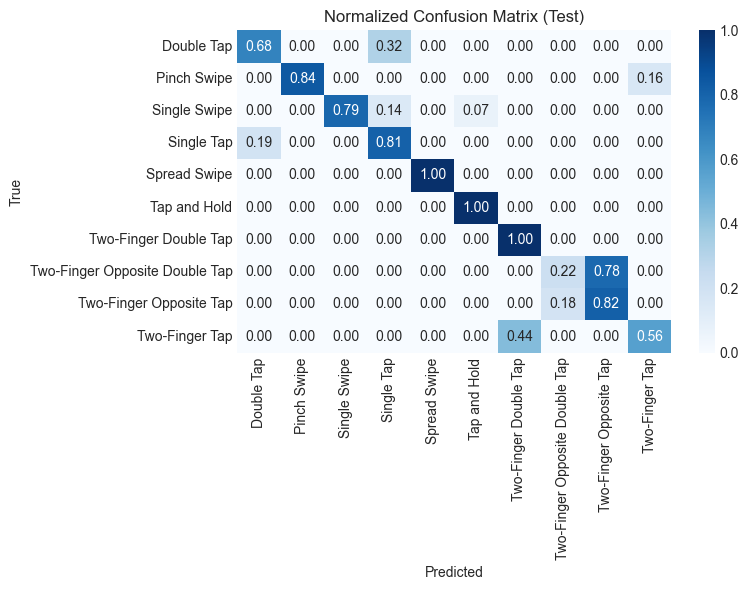

In [55]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred = best_model.predict(X_test_win)

print("Test classification report:\n",
      classification_report(y_test_win, y_test_pred, target_names=le.classes_))

cm = confusion_matrix(y_test_win, y_test_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

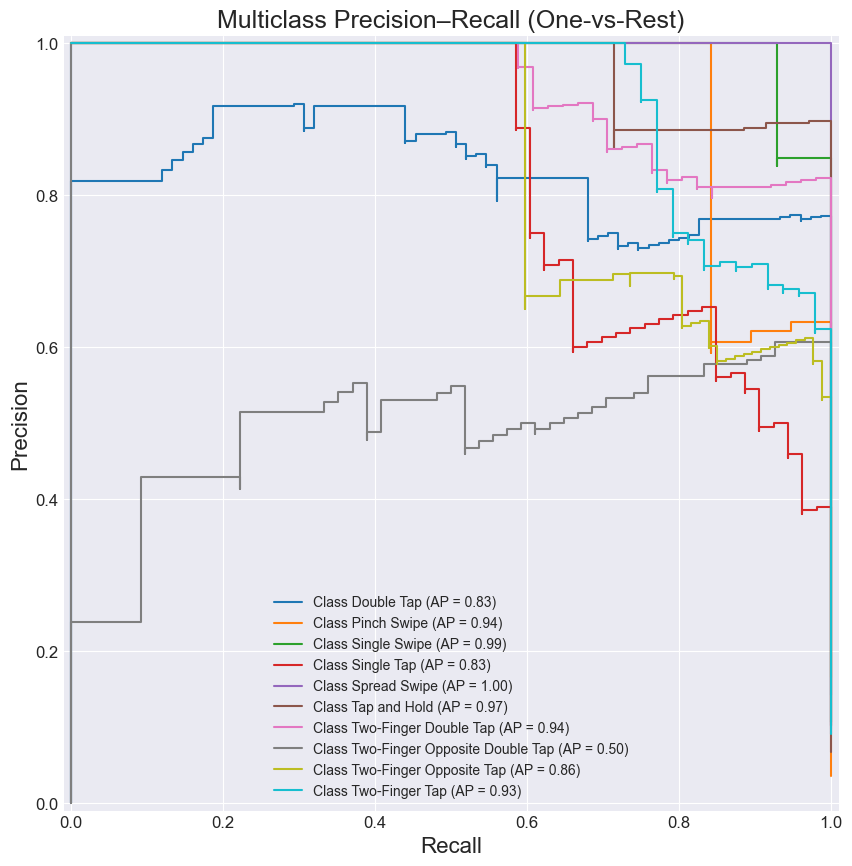

In [56]:
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.preprocessing import label_binarize
classes = best_model.classes_
n_classes = len(classes)

# predict probabilities
y_test_proba = best_model.predict_proba(X_test_win)

# binarize labels
y_test_bin = label_binarize(y_test_win, classes=classes)

fig, ax = plt.subplots(figsize=(10, 12))

for i, cls in enumerate(classes):
    cls_label = le.inverse_transform([cls])[0]
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_test_proba[:, i],
        name=f"Class {cls_label}",
        ax=ax
    )
ax.set_xlabel("Recall", fontsize=16)
ax.set_ylabel("Precision", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=12)
ax.set_title("Multiclass Precision–Recall (One-vs-Rest)", fontsize=18)
ax.legend()
plt.show()

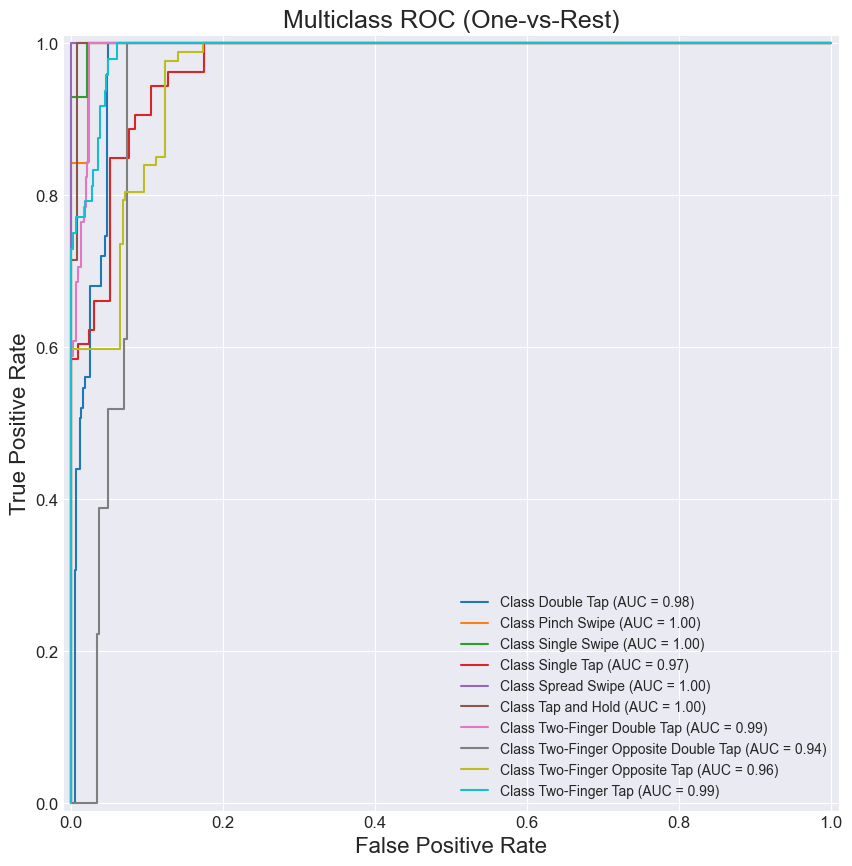

In [57]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize

classes = best_model.classes_
n_classes = len(classes)

y_test_proba = best_model.predict_proba(X_test_win)
y_test_bin = label_binarize(y_test_win, classes=classes)

fig, ax = plt.subplots(figsize=(10, 12))

for i, cls in enumerate(classes):
    cls_label = le.inverse_transform([cls])[0]
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_test_proba[:, i],
        name=f"Class {cls_label}",
        ax=ax
    )
ax.set_xlabel("False Positive Rate", fontsize=16)
ax.set_ylabel("True Positive Rate", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=12)
ax.set_title("Multiclass ROC (One-vs-Rest)", fontsize=18)
ax.legend()
plt.show()


In [58]:
# Store best model to disk
import joblib

model_filename = "best_class_gesture_classic_recognition_model.pkl"
joblib.dump(best_model, model_filename)

['best_class_gesture_classic_recognition_model.pkl']

## Test with Szenario

In [59]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    rt.title AS gesture,
    rtParent.title AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
WHERE rtParent.title = 'Szenarien'
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None


In [60]:
# Print counts of unique gestures per participant_id
counts = (
    szenarien_df_raw
    .groupby(['participant_id', 'gesture'])
    .size()
    .reset_index(name='count')
)

print(counts)

                          participant_id           gesture  count
0   6331fbd1-76bb-48d6-92a2-80a55a70d134   Bild vergrößern   1389
1   6331fbd1-76bb-48d6-92a2-80a55a70d134  Dateien kopieren   2099
2   6331fbd1-76bb-48d6-92a2-80a55a70d134    Musik Vorschau   1374
3   696b4743-9d39-4fb1-8271-90e7d48652af   Bild vergrößern   1013
4   696b4743-9d39-4fb1-8271-90e7d48652af  Dateien kopieren   1029
5   696b4743-9d39-4fb1-8271-90e7d48652af    Musik Vorschau    928
6   6a1b56e6-47ce-43cb-96cb-713d055d8f6d   Bild vergrößern   2817
7   6a1b56e6-47ce-43cb-96cb-713d055d8f6d  Dateien kopieren   2009
8   6a1b56e6-47ce-43cb-96cb-713d055d8f6d    Musik Vorschau   2355
9   707c3867-fe15-4b05-bf7b-fc5f3b501fb1   Bild vergrößern   1425
10  707c3867-fe15-4b05-bf7b-fc5f3b501fb1    Musik Vorschau   1195
11  754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0   Bild vergrößern    913
12  754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0  Dateien kopieren   1204
13  754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    Musik Vorschau   2362
14  d3b39f

In [61]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [62]:
is_null = szenarien_df_raw["group_id"].isnull()
null_block_start = is_null & (~is_null.shift(1, fill_value=False))
block_ids = null_block_start.cumsum()
szenarien_df_raw["group_id"] = szenarien_df_raw["group_id"].fillna("no_gesture_block_" + block_ids.astype(str))

In [ ]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        szenarien_df_raw[col] = szenarien_df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        szenarien_df_raw[col] = szenarien_df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        szenarien_df_raw[col] = szenarien_df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
szenarien_df_raw['motor_angle'] = szenarien_df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [64]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


In [65]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df.isna().sum()

id                            0
session_task_id               0
session_task_row_index        0
timestamp                     0
button_pressed                0
motor_angle                   0
gesture                       0
parent_gesture                0
participant_id                0
is_gesture                    0
marker_label              21846
group_id                      0
estimated_timestamp           0
timestamp_ms                  0
touch_1_position              0
touch_1_pressure              0
touch_1_channel               0
touch_2_position              0
touch_2_pressure              0
touch_2_channel               0
touch_3_position              0
touch_3_pressure              0
touch_3_channel               0
touch_4_position              0
touch_4_pressure              0
touch_4_channel               0
touch_5_position              0
touch_5_pressure              0
touch_5_channel               0
active_ids                    0
dtype: int64

In [66]:
# Print the marker_label counts
print(szenarien_df["marker_label"].value_counts())

marker_label
No Gesture                        3235
Tap and Hold                      2479
Spread Swipe                      1723
Single Swipe                      1450
Pinch Swipe                        838
Two-Finger Tap                     553
Two-Finger Double Tap              516
Two-Finger Opposite Double Tap     486
Double Tap                         367
Two-Finger Opposite Tap            315
Name: count, dtype: int64


In [67]:
streams = {}        # session_task_id -> X_stream (T, D)
streams_labels = {} # session_task_id -> marker_label per frame (T,)
streams_meta = {}

for sid, sdf in szenarien_df.groupby("session_task_id"):
    X_stream = sdf[SENSOR_COLUMNS].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    meta_stream = {
        "participant_id": sdf["participant_id"].iloc[0],
        "session_task_id": sid,
        "num_samples": len(sdf),
    }
    streams[sid] = X_stream
    streams_labels[sid] = y_stream
    streams_meta[sid] = meta_stream

In [80]:
# max_len = 200
max_len = 70
step_size = 10

print(f"Using max_len={max_len} for online prediction.")
def predict_stream_online(X_stream, y_stream):
    T, D = X_stream.shape
    preds = []
    probas = []
    real_labels = []

    windows = []
    for t_start in range(0, T - max_len + 1, step_size):
        t_end = t_start + max_len
        y_window = y_stream[t_start:t_end]
        valid_labels = [label for label in y_window if label is not None and label != "No Gesture"]
        if not valid_labels:
            continue
        windows.append((t_start, t_end))

    for (t_start, t_end) in windows:
        window_raw = X_stream[t_start:t_end]
        window = extract_features(window_raw, False)[0]
        y_window = y_stream[t_start:t_end]

        window_labels = [label for label in y_window if label is not None and label != "No Gesture"]
        most_common_labels = pd.Series(window_labels).mode()
        if most_common_labels.empty:
            continue
        most_common_label = most_common_labels.iloc[0]
        real_labels.append(most_common_label)

        window = np.nan_to_num(window, nan=0.0).reshape(1, -1)
        proba = best_model.predict_proba(window)[0]
        probas.append(proba)

        cls_idx = np.argmax(proba)
        label = le.classes_[cls_idx]
        preds.append(label)

    return np.array(preds), np.array(real_labels), np.array(probas), windows


Using max_len=70 for online prediction.


In [81]:
all_true = []
all_prediced = []
all_probabilities = []

total_streams = len(streams)
current_stream = 1
for sid, X_stream in streams.items():
    print(f"Predicting stream {current_stream}/{total_streams} (session_task_id={sid})...")
    current_stream += 1
    y_stream = streams_labels[sid]
    preds, real_labels, probas, windows = predict_stream_online(X_stream, y_stream)
    
    all_true.extend(real_labels)
    all_prediced.extend(preds)
    all_probabilities.extend(probas)

Predicting stream 1/20 (session_task_id=002f4422-1f7b-4859-8f03-467e1f752000)...
Predicting stream 2/20 (session_task_id=0542a515-ad14-49ec-84d7-c3b4e8b6ffe2)...
Predicting stream 3/20 (session_task_id=1428d33a-3bff-4f49-ba25-dca7d3980421)...
Predicting stream 4/20 (session_task_id=19bae408-9256-4cb3-930b-4beaa4875157)...
Predicting stream 5/20 (session_task_id=2789503c-76bf-4451-9bf7-9b7417c8b08e)...
Predicting stream 6/20 (session_task_id=319a52f3-2f36-4460-ba9d-a4346666683f)...
Predicting stream 7/20 (session_task_id=37f425a5-7c3c-4444-9bca-26e3fd5f0186)...
Predicting stream 8/20 (session_task_id=3be34428-0cf8-44c9-8b61-8172643e235d)...
Predicting stream 9/20 (session_task_id=4828a4ce-5192-4853-906e-1d79fd94da44)...
Predicting stream 10/20 (session_task_id=5658dcb6-a957-4027-a893-3b335e8ca212)...
Predicting stream 11/20 (session_task_id=5c21a030-cd27-4e99-b8c0-18f30cfa3fc3)...
Predicting stream 12/20 (session_task_id=6372259a-787d-4b7c-84b7-2eca71318068)...
Predicting stream 13/20 (

In [82]:
all_true_arr = np.array(all_true)
all_prediced_arr = np.array(all_prediced)
all_probabilities_arr = np.array(all_probabilities)

print(f"Unique true labels: {np.unique(all_true_arr)}")
print(f"Unique predicted labels: {np.unique(all_prediced_arr)}")

Unique true labels: ['Double Tap' 'Pinch Swipe' 'Single Swipe' 'Spread Swipe' 'Tap and Hold'
 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']
Unique predicted labels: ['Double Tap' 'Pinch Swipe' 'Single Swipe' 'Single Tap' 'Spread Swipe'
 'Tap and Hold' 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']


                                precision    recall  f1-score   support

                    Double Tap       0.34      0.14      0.20       114
                   Pinch Swipe       0.18      0.24      0.20       106
                  Single Swipe       0.33      0.41      0.37       273
                    Single Tap       0.00      0.00      0.00         0
                  Spread Swipe       0.34      0.14      0.20       261
                  Tap and Hold       0.56      0.07      0.13       301
         Two-Finger Double Tap       0.22      0.01      0.02       152
Two-Finger Opposite Double Tap       0.36      0.20      0.26        89
       Two-Finger Opposite Tap       0.11      0.48      0.17        92
                Two-Finger Tap       0.26      0.38      0.31       245

                      accuracy                           0.22      1633
                     macro avg       0.27      0.21      0.19      1633
                  weighted avg       0.34      0.22      0.22 

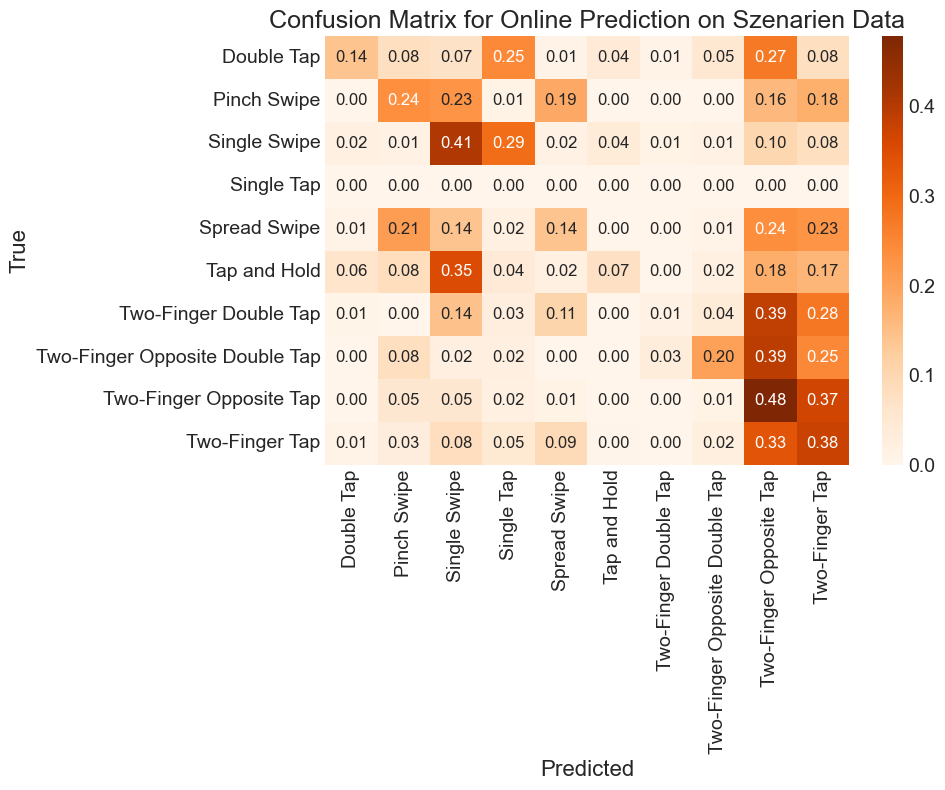

In [83]:
from sklearn.metrics import confusion_matrix, classification_report

y_true_int = le.transform(all_true)           # if marker labels use same names
y_pred_int = le.transform(all_prediced_arr)

used_labels = np.unique(np.concatenate([y_true_int, y_pred_int]))
used_target_names = le.inverse_transform(used_labels)
print(
    classification_report(
        y_true_int,
        y_pred_int,
        labels=used_labels,
        target_names=used_target_names
    )
)

cm = confusion_matrix(y_true_int, y_pred_int, labels=range(len(le.classes_)))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Oranges",
    annot_kws={"fontsize": 12}
)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Predicted", fontsize=16)
plt.ylabel("True", fontsize=16)
plt.title("Confusion Matrix for Online Prediction on Szenarien Data", fontsize=18)
plt.tight_layout()
plt.show()


In [84]:
# Print the top-k stats
from collections import defaultdict

def top_k_classification_report(
    y_true,
    y_proba,
    k=3,
    class_names=None
):
    n_classes = y_proba.shape[1]
    top_k_preds = np.argsort(y_proba, axis=1)[:, -k:]

    support = defaultdict(int)
    tp = defaultdict(int)
    pred_count = defaultdict(int)

    for i, true_cls in enumerate(y_true):
        support[true_cls] += 1

        for pred_cls in top_k_preds[i]:
            pred_count[pred_cls] += 1
            if pred_cls == true_cls:
                tp[pred_cls] += 1

    rows = []

    for cls in range(n_classes):
        sup = support[cls]
        if sup == 0:
            precision = recall = f1 = 0.0
        else:
            precision = tp[cls] / pred_count[cls] if pred_count[cls] > 0 else 0.0
            recall = tp[cls] / sup
            f1 = (
                2 * precision * recall / (precision + recall)
                if (precision + recall) > 0
                else 0.0
            )

        name = class_names[cls] if class_names is not None else str(cls)
        rows.append((name, precision, recall, f1, sup))

    # calculate averages (macro and weighted)
    for avg_type in ['macro avg', 'weighted avg']:
        # exclude the previous avg from the rows
        filtered_rows = [row for row in rows if row[0] not in ['macro avg', 'weighted avg']]
        if avg_type == 'macro avg':
            precision = np.mean([row[1] for row in filtered_rows])
            recall = np.mean([row[2] for row in filtered_rows])
            f1 = np.mean([row[3] for row in filtered_rows])
            sup = np.sum([row[4] for row in filtered_rows])
        else:
            total_sup = np.sum([row[4] for row in filtered_rows])
            precision = np.sum([row[1] * row[4] for row in filtered_rows]) / total_sup if total_sup > 0 else 0.0
            recall = np.sum([row[2] * row[4] for row in filtered_rows]) / total_sup if total_sup > 0 else 0.0
            f1 = np.sum([row[3] * row[4] for row in filtered_rows]) / total_sup if total_sup > 0 else 0.0
            sup = total_sup
        rows.append((avg_type, precision, recall, f1, sup))

    return rows

In [85]:
top1 = top_k_classification_report(
    y_true_int,
    all_probabilities_arr,
    k=1,
    class_names=le.classes_
)

top3 = top_k_classification_report(
    y_true_int,
    all_probabilities_arr,
    k=3,
    class_names=le.classes_
)

print(
    f"{'Class':35s}"
    f"{'P@1':>6s}{'R@1':>6s}{'F1@1':>7s} | "
    f"{'P@3':>6s}{'R@3':>6s}{'F1@3':>7s}{'Sup':>6s}"
)

for (c1, p1, r1, f1, sup), (_, p3, r3, f3, _) in zip(top1, top3):
    print(
        f"{c1:35s}"
        f"{p1:6.2f}{r1:6.2f}{f1:7.2f} | "
        f"{p3:6.2f}{r3:6.2f}{f3:7.2f}{sup:6d}"
    )

Class                                 P@1   R@1   F1@1 |    P@3   R@3   F1@3   Sup
Double Tap                           0.34  0.14   0.20 |   0.14  0.34   0.19   114
Pinch Swipe                          0.18  0.24   0.20 |   0.13  0.51   0.21   106
Single Swipe                         0.33  0.41   0.37 |   0.25  0.82   0.39   273
Single Tap                           0.00  0.00   0.00 |   0.00  0.00   0.00     0
Spread Swipe                         0.34  0.14   0.20 |   0.26  0.31   0.28   261
Tap and Hold                         0.56  0.07   0.13 |   0.33  0.20   0.25   301
Two-Finger Double Tap                0.22  0.01   0.02 |   0.12  0.12   0.12   152
Two-Finger Opposite Double Tap       0.36  0.20   0.26 |   0.12  0.44   0.18    89
Two-Finger Opposite Tap              0.11  0.48   0.17 |   0.06  0.61   0.12    92
Two-Finger Tap                       0.26  0.38   0.31 |   0.20  0.71   0.31   245
macro avg                            0.27  0.21   0.19 |   0.16  0.41   0.21  1633
weig

In [86]:
# Put all group_ids in windows
windows = []
window_lables = []
meta_data = []
for gid, gdf in szenarien_df.groupby("group_id"):
    if gdf["marker_label"].iloc[0] is None or gdf["marker_label"].iloc[0] == "No Gesture":
        continue
    X_window = extract_features(gdf[SENSOR_COLUMNS].to_numpy(dtype="float32"), False)[0]
    windows.append(X_window)
    window_lables.append(gdf["marker_label"].iloc[0])
    meta_data.append({
        "session_task_id": gdf["session_task_id"].iloc[0],
        "participant_id": gdf["participant_id"].iloc[0],
        "group_id": gid
    })

print(f"Created {len(windows)} windows from Szenarien data for group_id prediction.")

Created 145 windows from Szenarien data for group_id prediction.


In [87]:
# Print min and max length of windows
window_lengths = [w.shape[0] for w in windows]
print(f"Window lengths: min={min(window_lengths)}, max={max(window_lengths)}")
# Print count of labels
label_counts = pd.Series(window_lables).value_counts()
print("Window label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Window lengths: min=383, max=383
Window label counts:
  Two-Finger Tap: 29
  Single Swipe: 25
  Spread Swipe: 18
  Two-Finger Double Tap: 15
  Two-Finger Opposite Double Tap: 14
  Two-Finger Opposite Tap: 13
  Tap and Hold: 13
  Double Tap: 11
  Pinch Swipe: 7


In [88]:
# Predict each window
all_window_true = []
all_window_pred = []
all_window_proba = []

for X_window, true_label in zip(windows, window_lables):
    X_batch = X_window[np.newaxis, ...]  # (1, max_len, D)
    proba = best_model.predict_proba(X_batch)[0]
    
    all_window_proba.append(proba)

    cls_idx = np.argmax(proba)
    conf = proba[cls_idx]
    pred_label = le.classes_[cls_idx]

    all_window_true.append(true_label)
    all_window_pred.append(pred_label)
# Print unique all_window_true and all_window_pred labels
all_window_true = np.array(all_window_true)
all_window_pred = np.array(all_window_pred)
all_window_proba = np.array(all_window_proba)

In [89]:
y_window_true_int = le.transform(all_window_true)
y_window_pred_int = le.transform(all_window_pred)

              precision    recall  f1-score   support

           0       0.50      0.27      0.35        11
           1       0.27      0.43      0.33         7
           2       0.46      0.52      0.49        25
           3       0.00      0.00      0.00         0
           4       0.44      0.22      0.30        18
           5       0.33      0.08      0.12        13
           6       0.00      0.00      0.00        15
           7       0.86      0.43      0.57        14
           8       0.23      0.46      0.31        13
           9       0.38      0.55      0.45        29

    accuracy                           0.36       145
   macro avg       0.35      0.30      0.29       145
weighted avg       0.40      0.36      0.35       145



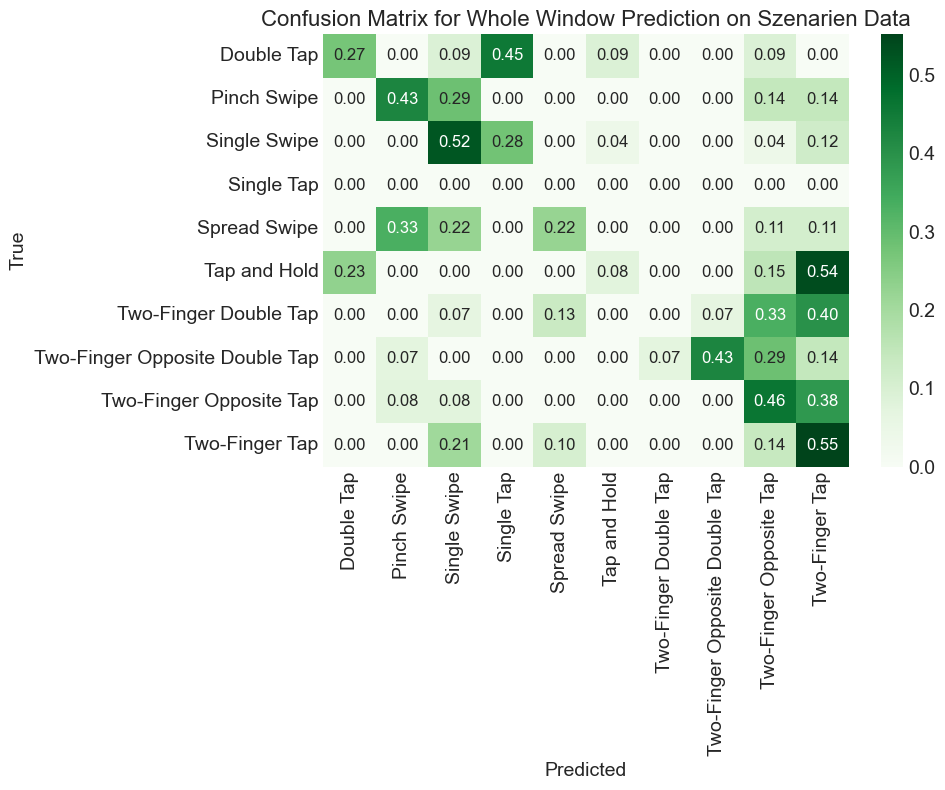

In [90]:
# Print confusion matrix and classification report for window predictions
used_labels_window = np.unique(np.concatenate([y_window_true_int, y_window_pred_int]))
used_labels_window_names = le.inverse_transform(used_labels_window)
print(
    classification_report(
        y_window_true_int,
        y_window_pred_int,
        labels=used_labels_window,
    )
)

cm_window = confusion_matrix(y_window_true_int, y_window_pred_int)
cm_window_norm = cm_window.astype('float') / cm_window.sum(axis=1)[:, np.newaxis]
cm_window_norm = np.nan_to_num(cm_window_norm)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    cm_window_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=used_labels_window_names,
    yticklabels=used_labels_window_names,
    annot_kws={"fontsize": 12}
)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("True", fontsize=14)
plt.title("Confusion Matrix for Whole Window Prediction on Szenarien Data", fontsize=16)
plt.tight_layout()
plt.show()

In [91]:
top1 = top_k_classification_report(
    y_window_true_int,
    all_window_proba,
    k=1,
    class_names=le.classes_
)

top3 = top_k_classification_report(
    y_window_true_int,
    all_window_proba,
    k=3,
    class_names=le.classes_
)

print(
    f"{'Class':35s}"
    f"{'P@1':>6s}{'R@1':>6s}{'F1@1':>7s} | "
    f"{'P@3':>6s}{'R@3':>6s}{'F1@3':>7s}{'Sup':>6s}"
)

for (c1, p1, r1, f1, sup), (_, p3, r3, f3, _) in zip(top1, top3):
    print(
        f"{c1:35s}"
        f"{p1:6.2f}{r1:6.2f}{f1:7.2f} | "
        f"{p3:6.2f}{r3:6.2f}{f3:7.2f}{sup:6d}"
    )

Class                                 P@1   R@1   F1@1 |    P@3   R@3   F1@3   Sup
Double Tap                           0.50  0.27   0.35 |   0.28  0.82   0.42    11
Pinch Swipe                          0.27  0.43   0.33 |   0.16  0.57   0.25     7
Single Swipe                         0.46  0.52   0.49 |   0.27  0.88   0.42    25
Single Tap                           0.00  0.00   0.00 |   0.00  0.00   0.00     0
Spread Swipe                         0.44  0.22   0.30 |   0.30  0.39   0.34    18
Tap and Hold                         0.33  0.08   0.12 |   0.13  0.31   0.19    13
Two-Finger Double Tap                0.00  0.00   0.00 |   0.12  0.13   0.12    15
Two-Finger Opposite Double Tap       0.86  0.43   0.57 |   0.35  0.43   0.39    14
Two-Finger Opposite Tap              0.23  0.46   0.31 |   0.09  0.46   0.15    13
Two-Finger Tap                       0.38  0.55   0.45 |   0.27  0.86   0.41    29
macro avg                            0.35  0.30   0.29 |   0.20  0.49   0.27   145
weig